<a href="https://colab.research.google.com/github/anaribeiro4/novo-repositorio/blob/main/Adaline..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Reconhecimento de Letras com Adaline

### Detalhes Técnicos:
* **Modelo**: ADAptive Linear NEuron (Adaline)[cite: 112].
* **Aprendizagem**: Regra Delta baseada na saída linear[cite: 115, 135].
* **Ativação**: Função degrau com saídas bipolares (+1 ou -1)[cite: 115, 186].

✓ Estrutura de diretórios criada com sucesso.
Gerando imagens das letras (A-Z) para treino e teste...
✓ Dataset criado: 390 imagens de treino e 130 de teste.

Iniciando Treinamento One-vs-All (26 Neurônios independentes)...
✓ Todos os neurônios foram treinados.

           RELATÓRIO DE DESEMPENHO            
Total de Amostras de Teste : 130
Total de Predições Corretas: 24
Acurácia Global do Sistema : 18.46%

Exemplos de erros cometidos pela rede (Top 5):
Esperado Predito
       S       G
       S       N
       D       B
       K       G
       K       Y


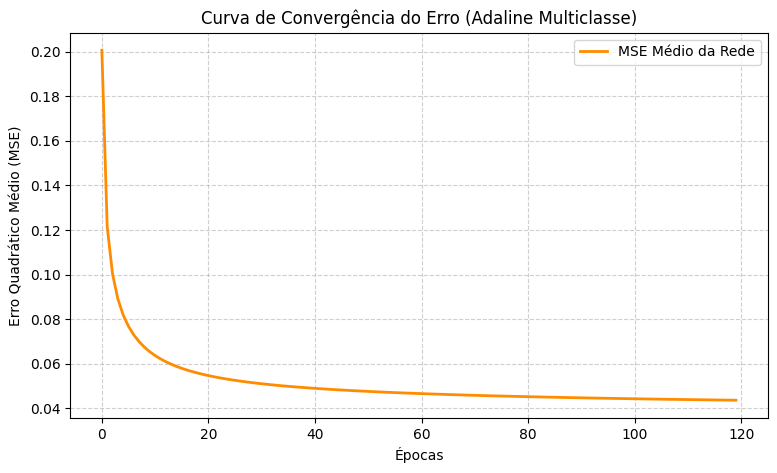

In [2]:
import os
import cv2
import random
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# =====================================================================
# ETAPA 1 & 2: CONFIGURAÇÃO DE DIRETÓRIOS E GERAÇÃO DO DATASET SINTÉTICO
# =====================================================================

def preparar_ambiente():
    """Cria a estrutura de pastas temporárias diretamente no ambiente do Colab."""
    for pasta in ['dados/treino', 'dados/teste', 'modelos', 'resultados']:
        if not os.path.exists(pasta):
            os.makedirs(pasta)
    print("✓ Estrutura de diretórios criada com sucesso.")

def gerar_variacoes_letra(letra, pasta_destino, num_variacoes=10):
    """Gera imagens de 40x40 pixels aplicando rotações e fontes variadas."""
    # Fontes TrueType nativas que o ambiente Ubuntu do Google Colab possui por padrão
    fontes_colab = ["LiberationSans-Regular.ttf", "LiberationSerif-Regular.ttf", "LiberationMono-Regular.ttf"]

    for i in range(num_variacoes):
        nome_fonte = random.choice(fontes_colab)
        tamanho_fonte = random.randint(24, 30)

        try:
            font = ImageFont.truetype(f"/usr/share/fonts/truetype/liberation/{nome_fonte}", tamanho_fonte)
        except IOError:
            font = ImageFont.load_default()

        # Cria imagem com fundo branco (255) em escala de cinza ('L')
        img = Image.new('L', (40, 40), color=255)
        draw = ImageDraw.Draw(img)

        # Centralização do caractere com leve deslocamento aleatório
        try:
            bbox = draw.textbbox((0, 0), letra, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except AttributeError:
            w, h = draw.textsize(letra, font=font)

        pos_x = (40 - w) // 2 + random.randint(-3, 3)
        pos_y = (40 - h) // 2 + random.randint(-3, 3)

        # Desenha a letra em preto (0)
        draw.text((pos_x, pos_y), letra, fill=0, font=font)

        # Aplica rotação aleatória leve para aumentar o poder de generalização da rede
        angulo = random.randint(-12, 12)
        img = img.rotate(angulo, resample=Image.BICUBIC, fillcolor=255)

        nome_arquivo = f"{letra}_{nome_fonte.split('-')[0]}_{i}.png"
        img.save(os.path.join(pasta_destino, nome_arquivo))

def construir_dataset():
    print("Gerando imagens das letras (A-Z) para treino e teste...")
    alfabeto = string.ascii_uppercase
    for letra in alfabeto:
        # 15 variações de treino e 5 variações de teste por caractere
        gerar_variacoes_letra(letra, 'dados/treino', num_variacoes=15)
        gerar_variacoes_letra(letra, 'dados/teste', num_variacoes=5)
    print(f"✓ Dataset criado: {len(alfabeto)*15} imagens de treino e {len(alfabeto)*5} de teste.")


# =====================================================================
# ETAPA 3: PRÉ-PROCESSAMENTO, EXTRAÇÃO DE CARACTERÍSTICAS E MAPEAMENTO BIPOLAR
# =====================================================================

def extrair_vetor_bipolar(caminho_imagem, tamanho_padrao=(20, 20)):
    """Lê, binariza de forma invertida, redimensiona para 20x20 e mapeia para [-1, 1]."""
    img = cv2.imread(caminho_imagem)
    if img is None:
        return None

    # Conversão para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Binarização invertida: Transforma fundo branco em 0 e caractere preto em 255
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    # Redimensiona para o tamanho de entrada da rede (20x20 = 400 pixels)
    resized = cv2.resize(binary, tamanho_padrao, interpolation=cv2.INTER_AREA)

    # Mapeamento Bipolar: Converte de [0, 255] para [-1.0, 1.0]
    vetor_bipolar = np.where(resized > 0, 1.0, -1.0)

    return vetor_bipolar.flatten()

def carregar_dados_pasta(pasta):
    """Vetoriza todas as imagens de um diretório e retorna as matrizes X e y."""
    X = []
    y = []
    for nome_arquivo in os.listdir(pasta):
        if nome_arquivo.endswith('.png'):
            letra = nome_arquivo.split('_')[0]
            vetor = extrair_vetor_bipolar(os.path.join(pasta, nome_arquivo))
            if vetor is not None:
                X.append(vetor)
                y.append(letra)
    return np.array(X), np.array(y)


# =====================================================================
# ETAPA 4: ARQUITETURA DA REDE NEURAL ADALINE
# =====================================================================

class Adaline:
    def __init__(self, n_features, lr=0.001, epochs=100):
        self.lr = lr
        self.epochs = epochs
        # Inicialização com valores aleatórios pequenos positivos e negativos (bipolares)
        self.w = np.random.uniform(-0.1, 0.1, n_features)
        self.b = np.random.uniform(-0.1, 0.1)
        self.historico_erros = []

    def funcao_linear(self, x):
        # Saída combinada antes da função de ativação descontínua
        return np.dot(x, self.w) + self.b

    def funcao_degrau_bipolar(self, y_linear):
        return np.where(y_linear >= 0, 1, -1)

    def treinar(self, X, t):
        self.historico_erros = []
        for epoca in range(self.epochs):
            erro_quadratico_epoca = 0.0

            for x_amostra, t_alvo in zip(X, t):
                y_linear = self.funcao_linear(x_amostra)
                erro = t_alvo - y_linear

                # Armazena o erro quadrático instantâneo da amostra
                erro_quadratico_epoca += 0.5 * (erro ** 2)

                # Regra Delta (Atualização por Gradiente Descendente Baseada no Erro Linear)
                self.w += self.lr * erro * x_amostra
                self.b += self.lr * erro

            # Erro Quadrático Médio (MSE) da época corrente
            self.historico_erros.append(erro_quadratico_epoca / len(X))


# =====================================================================
# ETAPA 5: PIPELINE DE TREINAMENTO MULTICLASSE (ONE-VS-ALL)
# =====================================================================

def treinar_sistema_completo(lr=0.001, epochs=100):
    X_treino, y_treino = carregar_dados_pasta('dados/treino')

    if len(X_treino) == 0:
        print("Erro: Carregamento de dados falhou.")
        return None

    alfabeto = list(string.ascii_uppercase)
    modelos_adaline = {}
    mse_acumulado_epocas = np.zeros(epochs)

    print(f"\nIniciando Treinamento One-vs-All ({len(alfabeto)} Neurônios independentes)...")

    for letra in alfabeto:
        # Criação do vetor alvo bipolar: +1 para a letra correta, -1 para todas as outras
        t_bipolar = np.where(y_treino == letra, 1, -1)

        # Instancia e treina o neurônio especialista da letra atual
        modelo = Adaline(n_features=X_treino.shape[1], lr=lr, epochs=epochs)
        modelo.treinar(X_treino, t_bipolar)

        modelos_adaline[letra] = modelo
        mse_acumulado_epocas += np.array(modelo.historico_erros)

    print("✓ Todos os neurônios foram treinados.")

    # Salva os pesos gerados
    with open('modelos/rede_adaline_caracteres.pkl', 'wb') as f:
        pickle.dump(modelos_adaline, f)

    # Retorna os modelos e o MSE médio global de toda a rede
    return modelos_adaline, (mse_acumulado_epocas / len(alfabeto))


# =====================================================================
# ETAPA 6: PREDICÃO, AVALIAÇÃO E RELATÓRIO DE MÉTRICAS
# =====================================================================

def classificar_caractere(vetor_caracteristicas, modelos):
    """Estratégia One-vs-All: O neurônio com a maior ativação linear vence."""
    maior_score = float('-inf')
    letra_predita = None

    for letra, neuronio in modelos.items():
        score_linear = neuronio.funcao_linear(vetor_caracteristicas)
        if score_linear > maior_score:
            maior_score = score_linear
            letra_predita = letra

    return letra_predita

def avaliar_sistema_completo(modelos, mse_historico):
    X_teste, y_teste = carregar_dados_pasta('dados/teste')

    acertos = 0
    predicoes = []

    for x, alvo in zip(X_teste, y_teste):
        predicao = classificar_caractere(x, modelos)
        predicoes.append(predicao)
        if predicao == alvo:
            acertos += 1

    acuracia = (acertos / len(y_teste)) * 100

    # 1. Exibir Relatório de Performance no Console
    print("\n==============================================")
    print("           RELATÓRIO DE DESEMPENHO            ")
    print("==============================================")
    print(f"Total de Amostras de Teste : {len(y_teste)}")
    print(f"Total de Predições Corretas: {acertos}")
    print(f"Acurácia Global do Sistema : {acuracia:.2f}%")
    print("==============================================")

    # 2. Estruturar tabela com Pandas para exportação
    df_resultados = pd.DataFrame({'Esperado': y_teste, 'Predito': predicoes})
    df_resultados.to_csv('resultados/metricas_finais.csv', index=False)

    # Mostrar erros (se houver) para análise de generalização
    erros = df_resultados[df_resultados['Esperado'] != df_resultados['Predito']]
    if not erros.empty:
        print(f"\nExemplos de erros cometidos pela rede (Top 5):\n{erros.head(5).to_string(index=False)}")
    else:
        print("\n✓ Incrível! A rede Adaline obteve 100% de acerto nas imagens de teste.")

    # 3. Gerar e exibir gráfico de convergência do MSE
    plt.figure(figsize=(9, 5))
    plt.plot(mse_historico, color='darkorange', linewidth=2, label='MSE Médio da Rede')
    plt.title('Curva de Convergência do Erro (Adaline Multiclasse)', fontsize=12)
    plt.xlabel('Épocas', fontsize=10)
    plt.ylabel('Erro Quadrático Médio (MSE)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.savefig('resultados/convergencia_mse.png')
    plt.show()


# =====================================================================
# BLOCÃO DE EXECUÇÃO PRINCIPAL
# =====================================================================

if __name__ == "__main__":
    # 1. Monta as pastas
    preparar_ambiente()

    # 2. Fabrica as imagens de treino e teste
    construir_dataset()

    # 3. Treina os 26 neurônios (ajustado para taxa de 0.001 e 120 épocas)
    modelos_treinados, historico_mse = treinar_sistema_completo(lr=0.001, epochs=120)

    # 4. Avalia os resultados e plota os gráficos
    if modelos_treinados is not None:
        avaliar_sistema_completo(modelos_treinados, historico_mse)